**LIME (Local Interpretable Model-agnostic Explanations)** is an explainable AI framework designed to explain the individual predictions of any black-box machine learning classifier or regressor.

Introduced by Marco Tulio Ribeiro, Sameer Singh, and Carlos Guestrin in 2016, LIME operates on a core premise: while a complex model's global decision boundary may be highly non-linear and impossible to inspect directly, its behavior **locally**—around a single specific data point—can be approximated with a simple, interpretable surrogate model.

---

### The Intuition

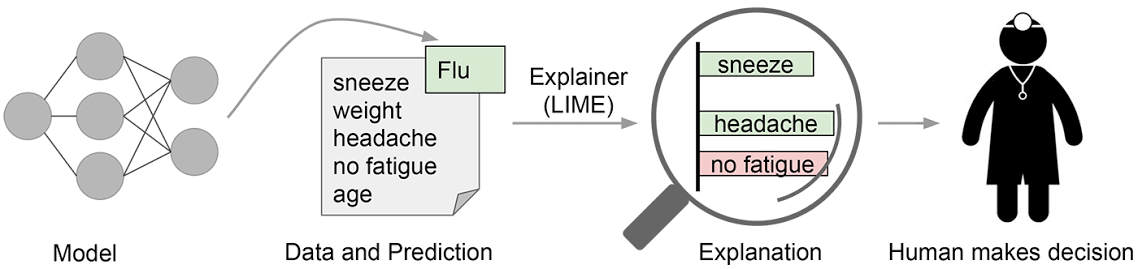

Instead of trying to explain how a complex model (such as a deep neural network or random forest) works across the entire dataset, LIME zooms in on a single instance:

1. It takes the instance of interest (e.g., a patient diagnosed with the flu) and creates minor variations by randomly perturbing its features (e.g., removing a symptom or tweaking a clinical value).
2. It passes these synthetic perturbed samples through the black-box model to record the predicted outputs.
3. It weights the perturbed samples based on their proximity to the original instance—samples closer to the original point receive much higher weight.
4. It fits a simple, interpretable model (such as a weighted linear regression) to these perturbed samples, using the regression coefficients as local feature importance scores.

---

### Mathematical Objective

LIME frames the search for an explanation as an optimization problem:

$$\text{Explanation}(x) = \arg\min_{g \in G} \mathcal{L}(f, g, \pi_x) + \Omega(g)$$

Where:

* $f(x)$ is the original black-box model being explained.
* $g$ is an interpretable surrogate model chosen from a class $G$ (such as sparse linear models or shallow decision trees).
* $\pi_x(z)$ is a proximity measure (distance kernel) that defines how close a perturbed instance $z$ is to the target instance $x$, typically computed as $\pi_x(z) = \exp\left(-\frac{D(x,z)^2}{\sigma^2}\right)$.
* $\mathcal{L}(f, g, \pi_x)$ is the measure of **local unfaithfulness**—how poorly the simple model $g$ approximates the complex model $f$ within the local neighborhood defined by $\pi_x$.
* $\Omega(g)$ is a complexity penalty that enforces simplicity (e.g., limiting the linear model to only $K$ non-zero features so it remains readable by humans).

---

### How LIME Handles Different Data Types

| Data Modality | Perturbation Method | How Features are Represented |
| --- | --- | --- |
| **Tabular Data** | Samples from Gaussian distributions based on dataset means and standard deviations. | Binary indicators showing whether continuous variables fall within specific quantile ranges. |
| **Text Classification** | Randomly removes words or tokens from the input text document. | Binary vectors indicating presence ($1$) or absence ($0$) of specific words in the perturbed string. |
| **Computer Vision** | Divides the image into contiguous regions called **superpixels**, then randomly turns superpixels on (original pixels) or off (grey/blurred patches). | Binary vectors indicating which superpixels are active in each perturbed image variation. |

---

### LIME vs. SHAP Comparison

| Dimension | LIME | SHAP |
| --- | --- | --- |
| **Theoretical Foundation** | Local linear surrogate approximation | Cooperative game theory (Shapley values) |
| **Mathematical Consistency** | Stochastic (varies slightly between runs due to random sampling) | Deterministic and uniquely satisfies Shapley consistency axioms |
| **Computation Speed** | Fast (controllable number of perturbed samples) | Can be computationally heavy (KernelSHAP) or fast for tree models (TreeSHAP) |
| **Scope of Explanation** | Strictly Local (explains single instances) | Both Local and Global (aggregates smoothly into summary plots) |
| **Feature Correlations** | Evaluates perturbed samples locally around the instance | Computes feature contributions across all subset coalitions |

---

### Strengths & Limitations

* **Strengths:**
* **Model-Agnostic:** Works with any algorithm (PyTorch, TensorFlow, Scikit-learn, XGBoost, or custom HTTP APIs).
* **Modality Flexible:** Native support for tabular, text, and computer vision models.
* **Fast Prototyping:** Requires relatively few perturbed samples to yield an intuitive local explanation.


* **Limitations:**
* **Instability:** Running LIME twice on the exact same data point can produce slightly different explanation weights due to the random sampling process.
* **Kernel Sensitivity:** Explanations are sensitive to the choice of the proximity kernel width ($\sigma$).
* **Out-of-Distribution Samples:** Random perturbations may generate unrealistic data combinations that fall outside the true data manifold.

In [16]:
%pip install lime xgboost scikit-learn pandas numpy matplotlib -q

### What this cell does

Installs the libraries required for the notebook. `pandas` and `numpy` prepare the applicant data, `xgboost` trains the classifier, `scikit-learn` creates the evaluation split, `matplotlib` renders the explanation, and `lime` builds the local surrogate model.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split

import lime
import lime.lime_tabular

np.random.seed(42)
n_samples = 2000

# Generate synthetic applicant features.
credit_score = np.random.normal(650, 70, n_samples).clip(300, 850)
annual_income = np.random.exponential(60000, n_samples) + 20000
debt_to_income = np.random.beta(2, 5, n_samples) * 100
loan_amount = np.random.normal(25000, 10000, n_samples).clip(2000, 100000)
late_payments_2yr = np.random.poisson(0.8, n_samples)
employment_years = np.random.exponential(5, n_samples).clip(0, 40)

risk_score = (
    -0.03 * credit_score
    -0.00005 * annual_income
    + 0.08 * debt_to_income
    + 0.00008 * loan_amount
    + 0.8 * late_payments_2yr
    - 0.15 * employment_years
    + np.random.normal(0, 1, n_samples)
)

default_risk = (risk_score > np.percentile(risk_score, 70)).astype(int)

df = pd.DataFrame({
    'Credit_Score': credit_score,
    'Annual_Income': annual_income,
    'Debt_to_Income_Ratio': debt_to_income,
    'Loan_Amount': loan_amount,
    'Late_Payments_2Yr': late_payments_2yr,
    'Employment_Years': employment_years,
    'Default_Risk': default_risk
})

df.head()

,Credit_Score,Annual_Income,Debt_to_Income_Ratio,Loan_Amount,Late_Payments_2Yr,Employment_Years,Default_Risk
0,684.769991,51364.428383,36.212615,31927.757697,0,7.695947,0
1,640.321499,24097.362834,75.915142,15569.905960,1,0.596722,1
2,695.338198,45738.199838,8.856190,16621.567040,0,6.440909,0
3,756.612090,27059.354293,33.788482,18095.222884,0,2.436023,0
4,633.609264,119089.142605,56.080133,19034.370704,1,0.381050,0


### What this cell does

Imports the modeling and LIME packages, then creates a reproducible synthetic credit dataset with six applicant attributes. The risk formula combines financial stress, repayment history, and employment stability to create the binary `Default_Risk` target: `0` means approved and `1` means denied.

In [18]:
X = df.drop(columns=['Default_Risk'])
y = df['Default_Risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    eval_metric='logloss',
    random_state=42
)
model.fit(X_train, y_train)

print(f"Test Accuracy: {model.score(X_test, y_test):.2%}")

Test Accuracy: 87.75%


### What this cell does

Separates the applicant features from the target, creates stratified training and test sets, and trains the XGBoost classifier. The printed test accuracy gives a quick check of how well the black-box model predicts unseen applicants before LIME explains one decision.

In [19]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.to_numpy(),
    feature_names=X_train.columns.tolist(),
    class_names=['Approved (0)', 'Denied (1)'],
    mode='classification',
    kernel_width=3.0,
    random_state=42
)

print(f"LIME explainer configured with {X_train.shape[1]} features.")

LIME explainer configured with 6 features.


### What this cell does

Initializes `LimeTabularExplainer` with the training data so LIME can learn feature ranges and distributions for realistic perturbations. It also names the two classes and fixes the random state so the local explanation is reproducible.

In [20]:
denied_indices = np.flatnonzero(model.predict(X_test) == 1)
if len(denied_indices) == 0:
    raise ValueError("No denied applicant was predicted in the test set.")

target_idx = denied_indices[0]
target_instance = X_test.iloc[target_idx]

def predict_proba_for_lime(rows):
    return model.predict_proba(pd.DataFrame(rows, columns=X_train.columns))

exp = explainer.explain_instance(
    data_row=target_instance.to_numpy(),
    predict_fn=predict_proba_for_lime,
    num_features=6
)

print(f"Prediction Probabilities: {model.predict_proba(target_instance.to_frame().T)[0]}")
print("\nLocal Feature Weights (LIME):")
for feature, weight in exp.as_list():
    print(f"{feature:<45} : {weight:+.4f}")

Prediction Probabilities: [0.37962908 0.6203709 ]

Local Feature Weights (LIME):
Credit_Score <= 607.94                        : +0.3902
Annual_Income <= 36565.40                     : +0.2504
Loan_Amount <= 18272.42                       : -0.1058
16.96 < Debt_to_Income_Ratio <= 26.95         : -0.1016
Late_Payments_2Yr <= 0.00                     : -0.0727
Employment_Years <= 1.51                      : +0.0604


### What this cell does

Selects an applicant predicted as denied and asks LIME to explain that single prediction. LIME creates nearby synthetic applicants, sends them through the model's probability interface, and fits a weighted local linear model. The resulting feature weights show which conditions support or oppose the denied classification.

### What this cell does

Converts the LIME explanation into a Matplotlib figure and displays it inline. The bars summarize the local surrogate's feature weights, making the individual approval or denial reasoning easier to inspect visually.

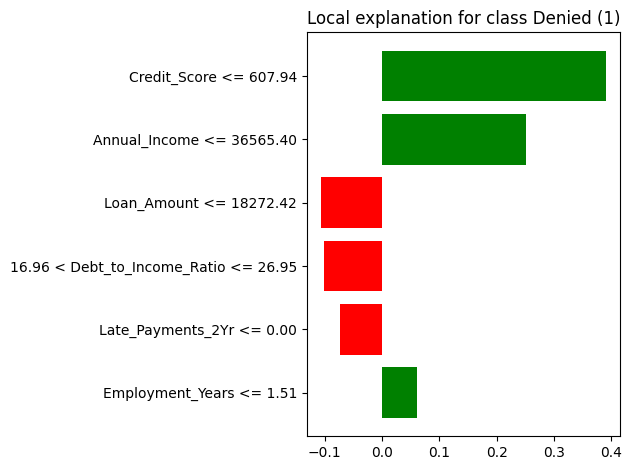

Static explanation saved as 'lime_explanation_customer.png'


In [23]:
fig = exp.as_pyplot_figure()
fig.tight_layout()

# GitHub renders the executed Matplotlib output stored in the notebook.
fig.savefig("lime_explanation_customer.png", dpi=150, bbox_inches="tight")
display(fig)
plt.close(fig)

print("Static explanation saved as 'lime_explanation_customer.png'")

### What this cell does

Renders the LIME explanation as a static Matplotlib image and embeds it in the notebook output. The embedded PNG is visible in GitHub's notebook viewer after the notebook is executed and committed. The separate PNG file can also be downloaded or shared.